<a href="https://colab.research.google.com/github/victorealeal/mod-1---regress-o/blob/main/Profissao_Cientista_de_Dados_M17_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [47]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("/content/CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';', decimal=',', thousands='.')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,50000.0,Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,100000.0,Master's Degree,Married,2,Owned,High
2,35.0,Female,75000.0,Doctorate,Married,1,Owned,High
3,40.0,Male,125000.0,High School Diploma,Single,0,Owned,High
4,45.0,Female,100000.0,Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,150000.0,Master's Degree,Married,0,Owned,High
6,26.0,Female,40000.0,Associate's Degree,Single,0,Rented,Average
7,31.0,Male,60000.0,Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,80000.0,Master's Degree,Married,2,Owned,High
9,NaN,Male,105000.0,Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [49]:

#verificando os tipos de dados
df.info()

df['Income'].unique()
df['Credit Score'].unique()

# A coluna 'Income' agora é carregada diretamente como numérica na célula rZIA-ZuQFI4N.
# Portanto, as transformações explícitas aqui não são mais necessárias.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    float64
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.4+ KB


array(['High', 'Average', 'Low'], dtype=object)

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [51]:
print(df.isnull().sum())

# após identificar que a idade é o unico dado faltante, agora precisa-se verificar a distribuição da idade pela mediana.
df['Age'].describe()

# os dados ausentes serão substituidos pelo valor da mediana, visto que as idades estão entre 25 e 53, e serão menos afetadas pelos extremos.
df['Age'] = df['Age'].fillna(df['Age'].median())

Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64


**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [52]:
for coluna in df.select_dtypes(include='object').columns:
    print(f'\n{coluna}:')
    print(df[coluna].value_counts())

# Foram verificadas as variáveis categóricas através dos valores únicose suas frequências. Não foram identificados erros de digitação ou
# inconsistências nas categorias, portanto não foi necessário realizar alterações.


Gender:
Gender
Female    86
Male      78
Name: count, dtype: int64

Education:
Education
Bachelor's Degree      42
Master's Degree        36
Doctorate              31
High School Diploma    30
Associate's Degree     25
Name: count, dtype: int64

Marital Status:
Marital Status
Married    87
Single     77
Name: count, dtype: int64

Home Ownership:
Home Ownership
Owned     111
Rented     53
Name: count, dtype: int64

Credit Score:
Credit Score
High       113
Average     36
Low         15
Name: count, dtype: int64


# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

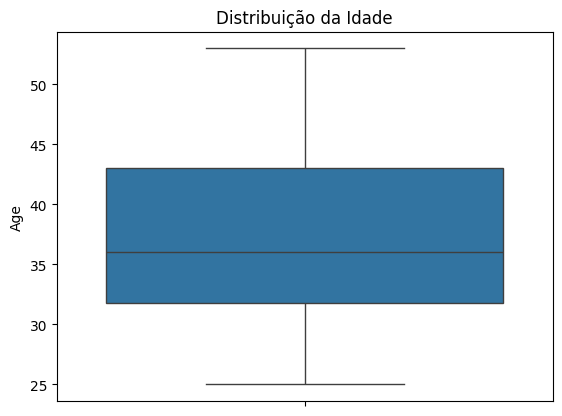

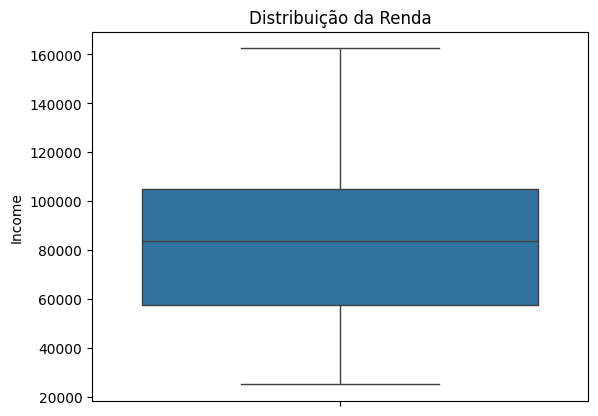

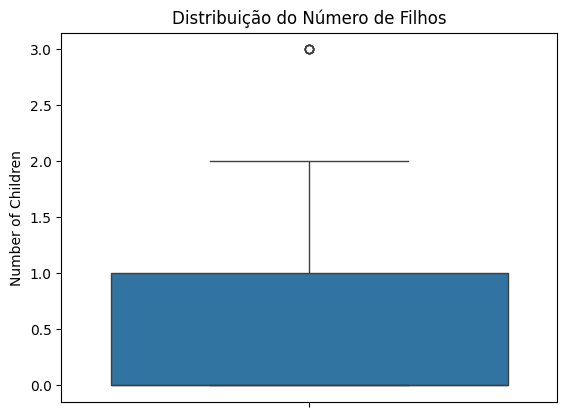

In [53]:
df.describe()

import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df, y='Age')
plt.title('Distribuição da Idade')
plt.show()



sns.boxplot(data=df, y='Income')
plt.title('Distribuição da Renda')
plt.show()




sns.boxplot(data=df, y='Number of Children')
plt.title('Distribuição do Número de Filhos')
plt.show()

# Idade: perfil relativamente concentrado entre adultos de 25–53 anos, sem outliers aparentes.
#Renda: é a variável com maior dispersão, indo de €25 mil a €162,5 mil, mas o gráfico não identificou outliers aparentes.
#Número de filhos: a maioria está concentrada entre 0 e 1 filho, e o valor 3 aparece como possível outlier.

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

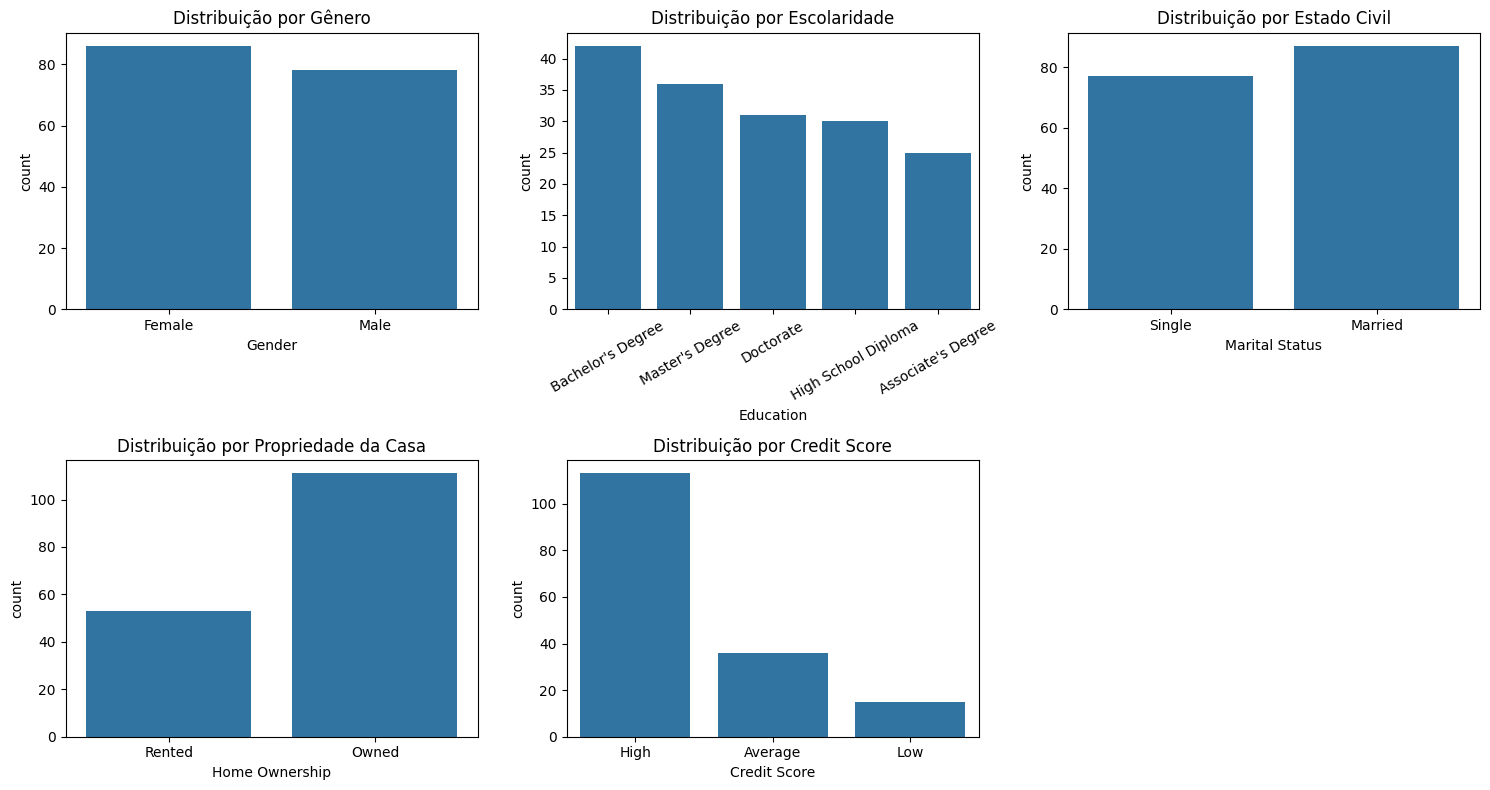

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Gender
sns.countplot(data=df, x='Gender', ax=axes[0, 0])
axes[0, 0].set_title('Distribuição por Gênero')

# Education
sns.countplot(data=df, x='Education', ax=axes[0, 1])
axes[0, 1].set_title('Distribuição por Escolaridade')
axes[0, 1].tick_params(axis='x', rotation=30)

# Marital Status
sns.countplot(data=df, x='Marital Status', ax=axes[0, 2])
axes[0, 2].set_title('Distribuição por Estado Civil')

# Home Ownership
sns.countplot(data=df, x='Home Ownership', ax=axes[1, 0])
axes[1, 0].set_title('Distribuição por Propriedade da Casa')

# Credit Score
sns.countplot(data=df, x='Credit Score', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição por Credit Score')

# Remove o espaço vazio do sexto gráfico
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

#insights
#Gênero: é relativamente equilibrada, com uma pequena predominância do gênero feminino, que representa aproximadamente 52,4% da amostra.
#Escolaridade: A categoria mais frequente é Bachelor's Degree, enquanto Associate's Degree apresenta a menor frequência. A distribuição é relativamente diversificada, sem uma concentração muito grande em uma única categoria
#Estado civil: Há uma distribuição relativamente equilibrada entre casados e solteiros, porém observa-se uma predominância de pessoas casadas, que representam aproximadamente 53% da amostra.
#Propriedade de casa: Existe uma predominância significativa de pessoas que possuem imóvel próprio, representando aproximadamente 67,7% da amostra, enquanto 32,3% vivem em imóvel alugado.
# Credit score: A categoria High apresenta uma forte predominância, representando aproximadamente 68,9% da amostra. Já a categoria Low é a menos frequente, com cerca de 9,1% dos indivíduos.
#Portanto, a distribuição está bastante concentrada em classificações de crédito alta


**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

In [55]:
df[df['Number of Children'] == 3]

#O valor 3 foi identificado como possível outlier na variável Number of Children.
#Após a análise dos registros, verificou-se que existem cinco ocorrências e não foram encontradas inconsistências.
#Por representar um valor possível e válido, os registros foram mantidos na base, sem necessidade de tratamento

# Não foram identificadas inconsistências ou erros de digitação nas variáveis categóricas.
# As categorias estão padronizadas e, portanto, não foi necessário realizar tratamento ou exclusão.

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
4,45.0,Female,100000.0,Bachelor's Degree,Married,3,Owned,High
33,45.0,Female,105000.0,Bachelor's Degree,Married,3,Owned,High
65,45.0,Female,110000.0,Bachelor's Degree,Married,3,Owned,High
97,45.0,Female,115000.0,Bachelor's Degree,Married,3,Owned,High
139,45.0,Female,105000.0,Bachelor's Degree,Married,3,Owned,High


**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



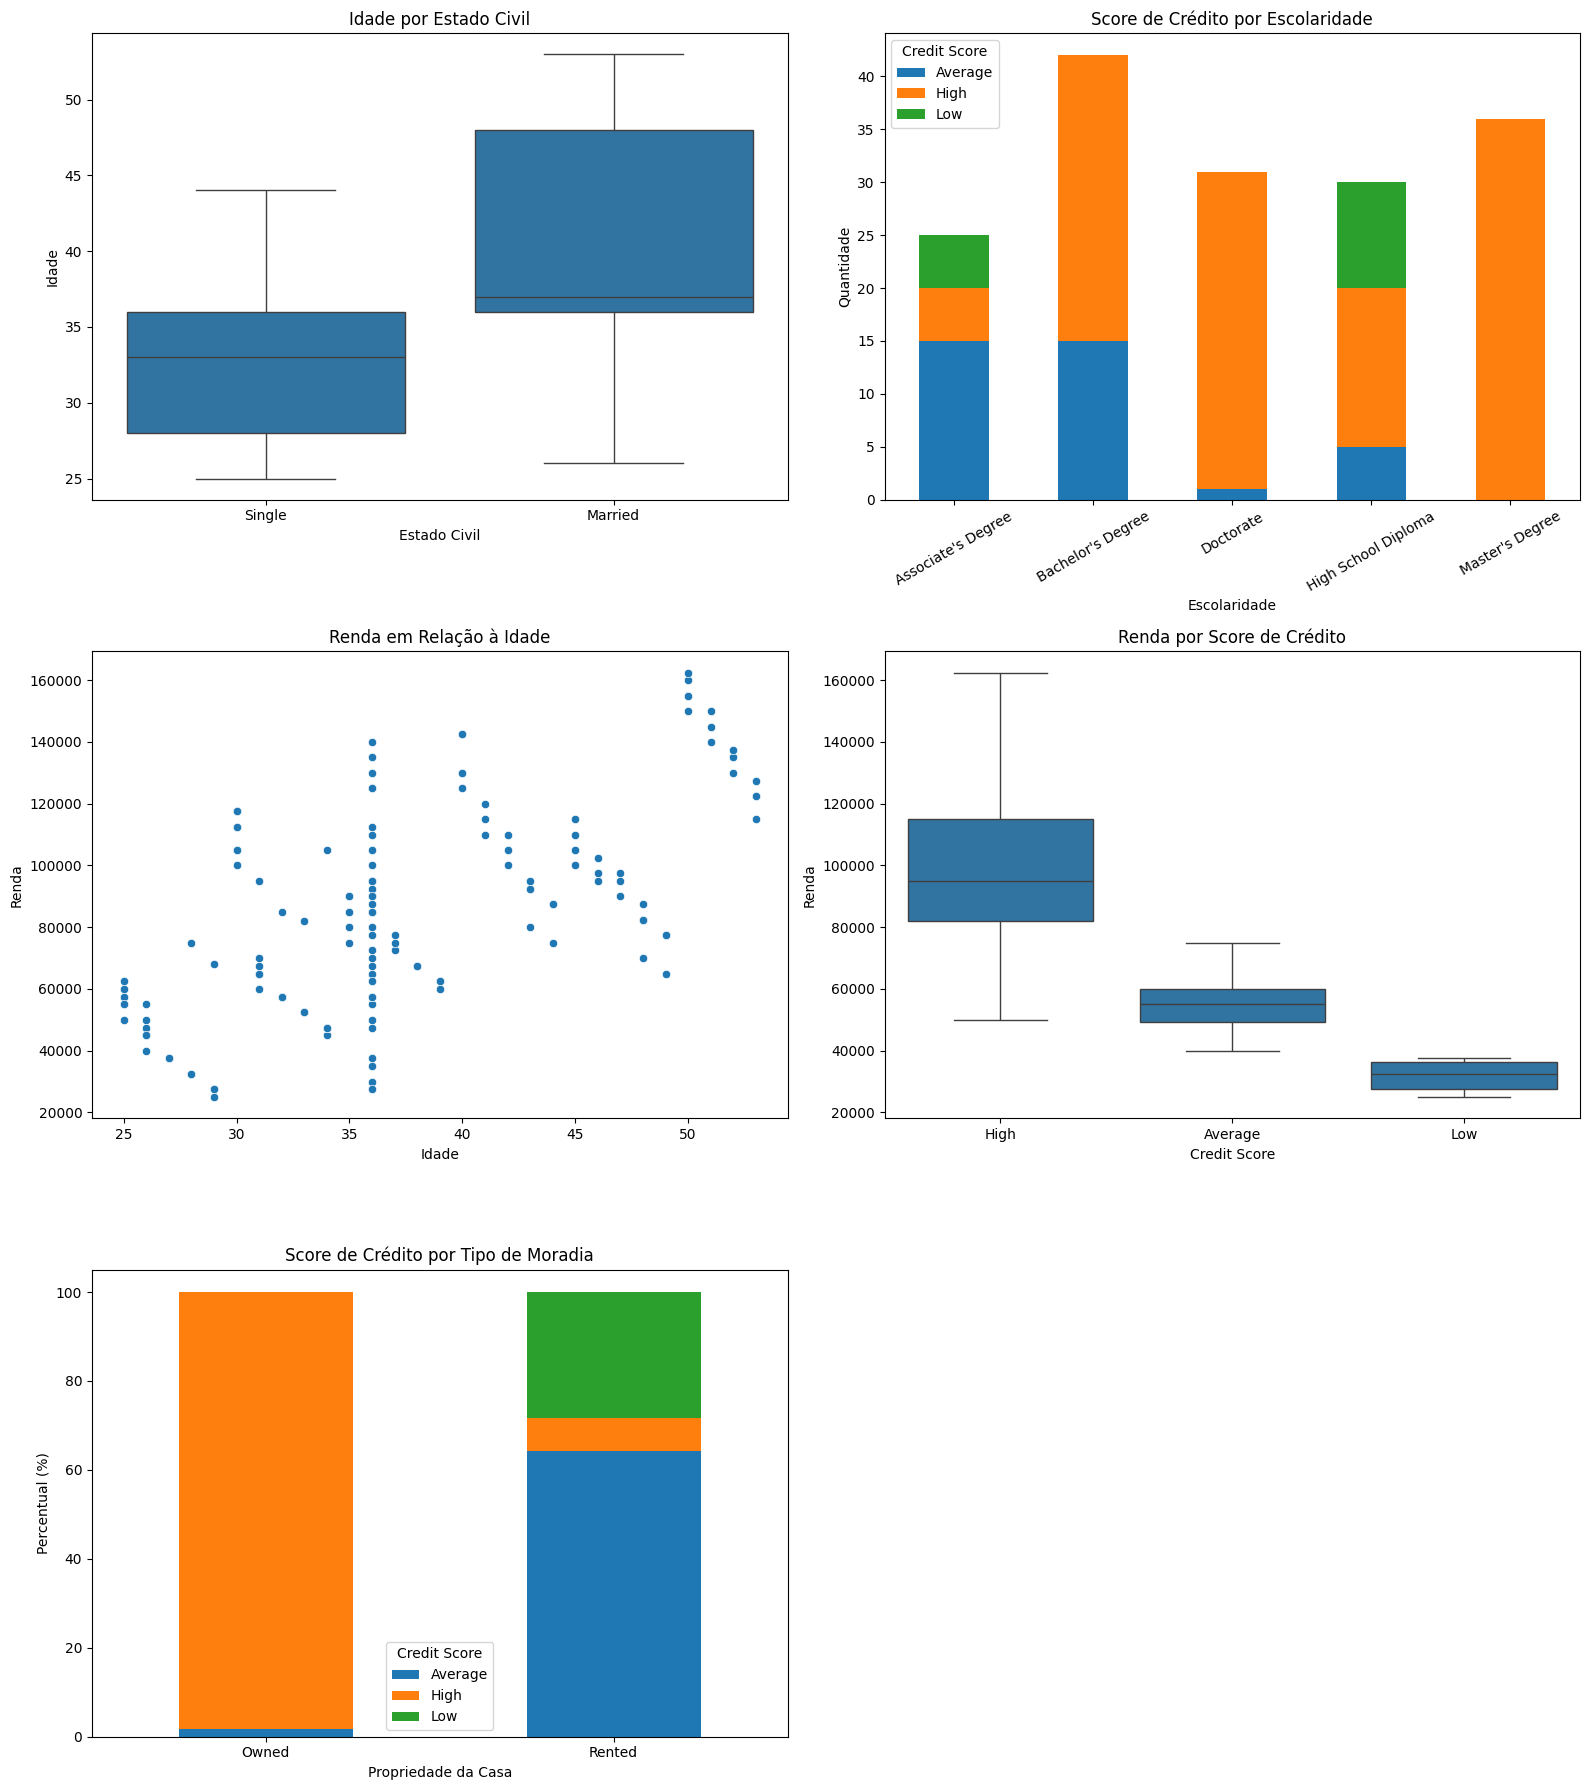

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Idade x Estado Civil
sns.boxplot(data=df, x='Marital Status', y='Age', ax=axes[0, 0])
axes[0, 0].set_title('Idade por Estado Civil')
axes[0, 0].set_xlabel('Estado Civil')
axes[0, 0].set_ylabel('Idade')

#Observamos que as pessoas casadas tendem a ser mais velhas, com uma mediana de idade maior em comparação com as pessoas solteiras.
#As idades dos casados também mostram uma menor dispersão em comparação com os solteiros, que apresentam uma faixa etária mais ampla.

# 2. Score x Escolaridade
pd.crosstab(df['Education'], df['Credit Score']).plot(
    kind='bar',
    stacked=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Score de Crédito por Escolaridade')
axes[0, 1].set_xlabel('Escolaridade')
axes[0, 1].set_ylabel('Quantidade')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].legend(title='Credit Score')

#Parece haver uma correlação positiva entre escolaridade e Credit Score.
#Indivíduos com níveis de escolaridade mais altos (como Mestrado e Doutorado) tendem a ter uma proporção maior de Credit Score 'High',
# enquanto aqueles com Ensino Médio tendem a ter uma proporção maior de Credit Score 'Low' ou 'Average'.

# 3. Renda x Idade
sns.scatterplot(data=df, x='Age', y='Income', ax=axes[1, 0])
axes[1, 0].set_title('Renda em Relação à Idade')
axes[1, 0].set_xlabel('Idade')
axes[1, 0].set_ylabel('Renda')

# 4. Renda x Score
sns.boxplot(data=df, x='Credit Score', y='Income', ax=axes[1, 1])
axes[1, 1].set_title('Renda por Score de Crédito')
axes[1, 1].set_xlabel('Credit Score')
axes[1, 1].set_ylabel('Renda')

#Não há uma correlação linear muito forte, mas pode-se observar uma tendência de que a renda tende a aumentar com a idade até um certo
#ponto e depois se estabiliza, ou apresenta maior dispersão, o que é comum em dados de renda. Não há um padrão muito claro de aumento
#constante.

# 5. Casa própria x Score
pct = pd.crosstab(
    df['Home Ownership'],
    df['Credit Score'],
    normalize='index'
) * 100

pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[2, 0]
)

axes[2, 0].set_title('Score de Crédito por Tipo de Moradia')
axes[2, 0].set_xlabel('Propriedade da Casa')
axes[2, 0].set_ylabel('Percentual (%)')
axes[2, 0].tick_params(axis='x', rotation=0)
axes[2, 0].legend(title='Credit Score')

#Clientes que possuem casa própria (Owned) apresentam uma proporção significativamente maior de Credit Score 'High' em comparação com
#aqueles que alugam (Rented). Por outro lado, clientes que alugam têm uma proporção maior de Credit Score 'Average' e 'Low'.
#Isso sugere que a propriedade da casa é um indicador forte de um Credit Score mais elevado.

# Deixar o último espaço vazio
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

### Novas Perguntas para Análise Multivariada

**1. Qual a relação entre `Credit Score`, `Educação` e `Renda`?**

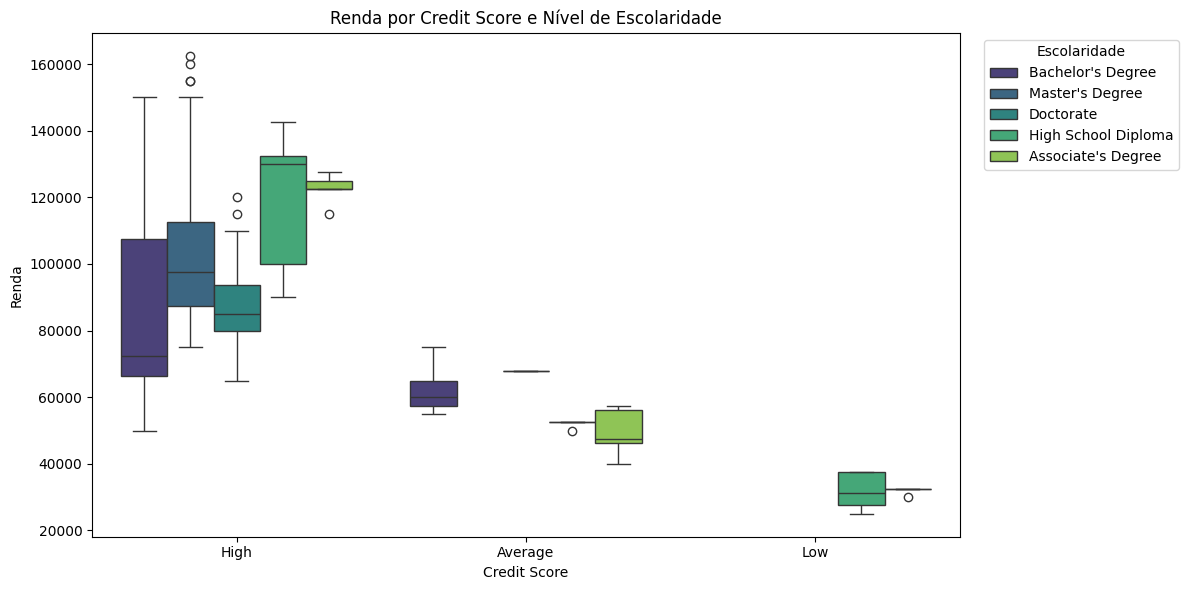

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Credit Score',
    y='Income',
    hue='Education',
    palette='viridis'
)

plt.title('Renda por Credit Score e Nível de Escolaridade')
plt.xlabel('Credit Score')
plt.ylabel('Renda')

plt.legend(title='Escolaridade', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Insights:** Observamos que, dentro de cada `Credit Score`, a renda tende a aumentar com o nível de escolaridade. Por exemplo, pessoas com `Credit Score` 'High' e Doutorado geralmente têm rendas mais altas do que aquelas com `Credit Score` 'High' e Ensino Médio. Isso sugere que a educação é um fator importante que contribui para rendas mais elevadas, o que, por sua vez, está associado a Scores de Crédito melhores.

### Pergunta 2: Como a Idade e a Propriedade da Casa influenciam o Credit Score?

Vamos investigar a distribuição etária em relação ao `Credit Score`, diferenciando entre aqueles que possuem casa própria e aqueles que alugam. Isso pode revelar se a idade e a propriedade de casa interagem na determinação da pontuação de crédito.

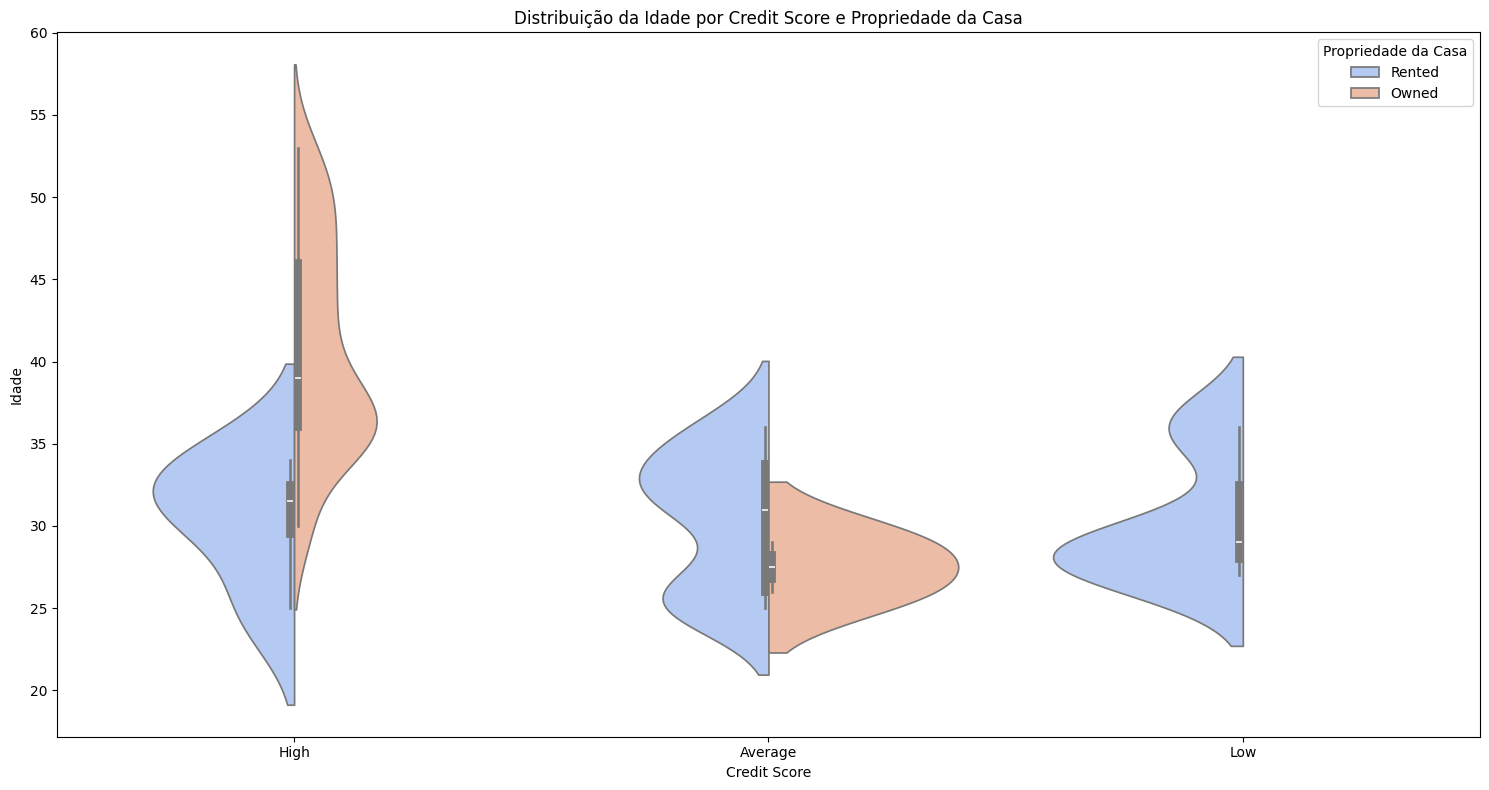

In [59]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15, 8))
sns.violinplot(data=df, x='Credit Score', y='Age', hue='Home Ownership', split=True, palette='coolwarm')
plt.title('Distribuição da Idade por Credit Score e Propriedade da Casa')
plt.xlabel('Credit Score')
plt.ylabel('Idade')
plt.legend(title='Propriedade da Casa')
plt.tight_layout()
plt.show()

**Insights:** Este gráfico revela padrões interessantes. Para `Credit Score` 'High', vemos que a mediana de idade é mais alta para proprietários de casas, o que faz sentido, já que a aquisição de imóvel geralmente ocorre em idades mais avançadas. Em Scores de Crédito 'Average' e 'Low', a distribuição da idade para locatários e proprietários pode ser mais similar ou até mesmo mais jovem para locatários. A posse de imóvel, muitas vezes, é um sinal de estabilidade financeira e pode ser um fator contribuinte para um score alto em idades mais maduras.

### Pergunta 3: Existe uma diferença no Credit Score entre Gênero e Estado Civil?

Esta análise busca entender se o `Credit Score` varia significativamente entre os gêneros e diferentes estados civis, investigando possíveis interações entre essas duas variáveis categóricas.


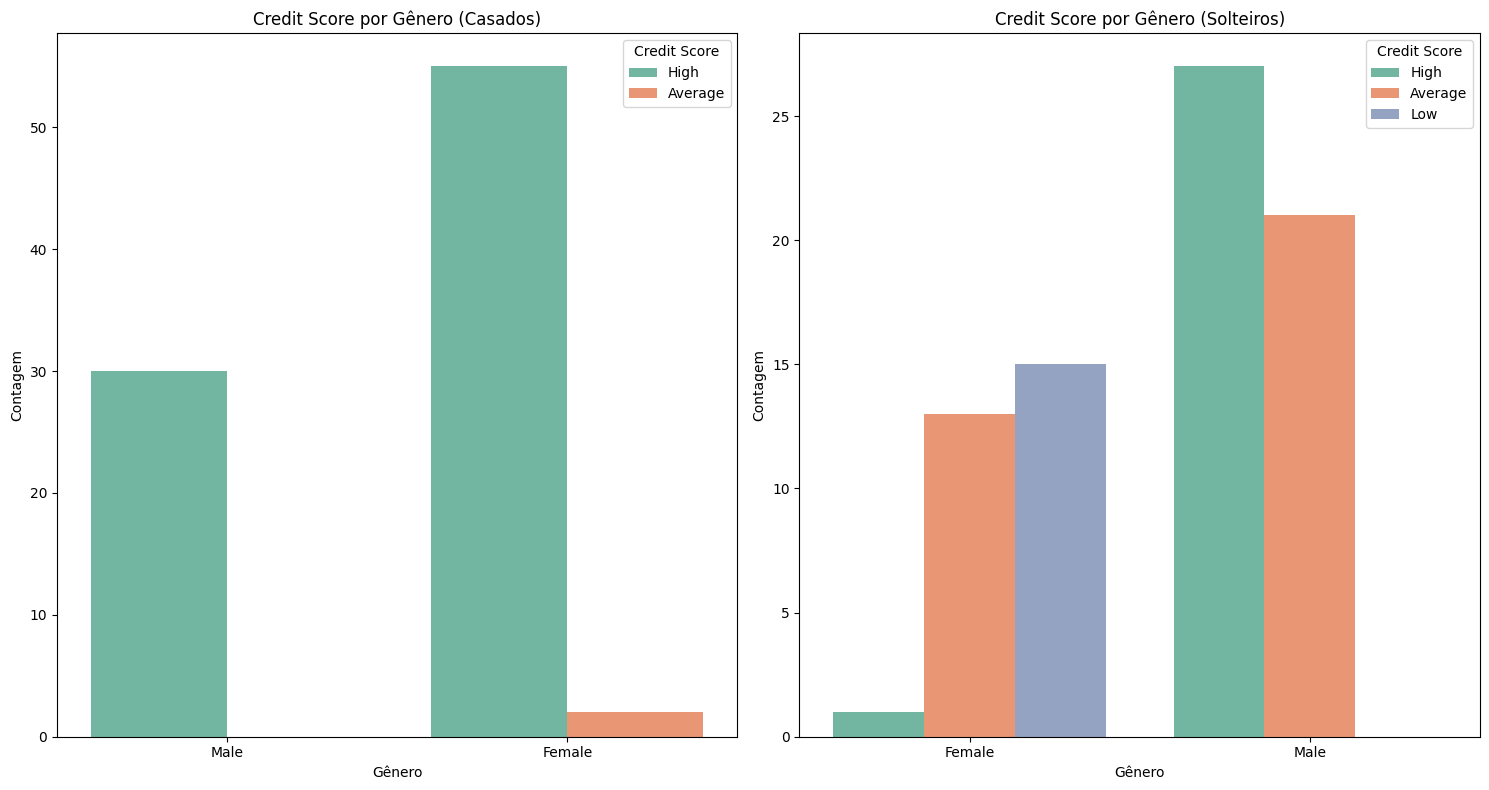

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot para Marital Status = 'Married'
sns.countplot(data=df[df['Marital Status'] == 'Married'], x='Gender', hue='Credit Score', palette='Set2', ax=axes[0])
axes[0].set_title('Credit Score por Gênero (Casados)')
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Contagem')
axes[0].legend(title='Credit Score')

# Plot para Marital Status = 'Single'
sns.countplot(data=df[df['Marital Status'] == 'Single'], x='Gender', hue='Credit Score', palette='Set2', ax=axes[1])
axes[1].set_title('Credit Score por Gênero (Solteiros)')
axes[1].set_xlabel('Gênero')
axes[1].set_ylabel('Contagem')
axes[1].legend(title='Credit Score')

plt.tight_layout()
plt.show()

**Insights:** Ao analisar o `Credit Score` por `Gênero` e `Estado Civil`, podemos observar se há diferenças notáveis. Por exemplo, pode-se verificar se homens casados tendem a ter um perfil de `Credit Score` diferente de mulheres casadas, e como isso se compara com as pessoas solteiras de ambos os gêneros. Essa análise pode revelar se certas combinações demográficas estão mais propensas a ter scores altos, médios ou baixos, o que pode ser útil para estratégias de segmentação de clientes ou para identificar possíveis vieses nos dados ou no modelo de crédito.

### Pergunta 4: Qual a influência do `Number of Children` e `Home Ownership` no `Credit Score`?

<Figure size 1200x700 with 0 Axes>

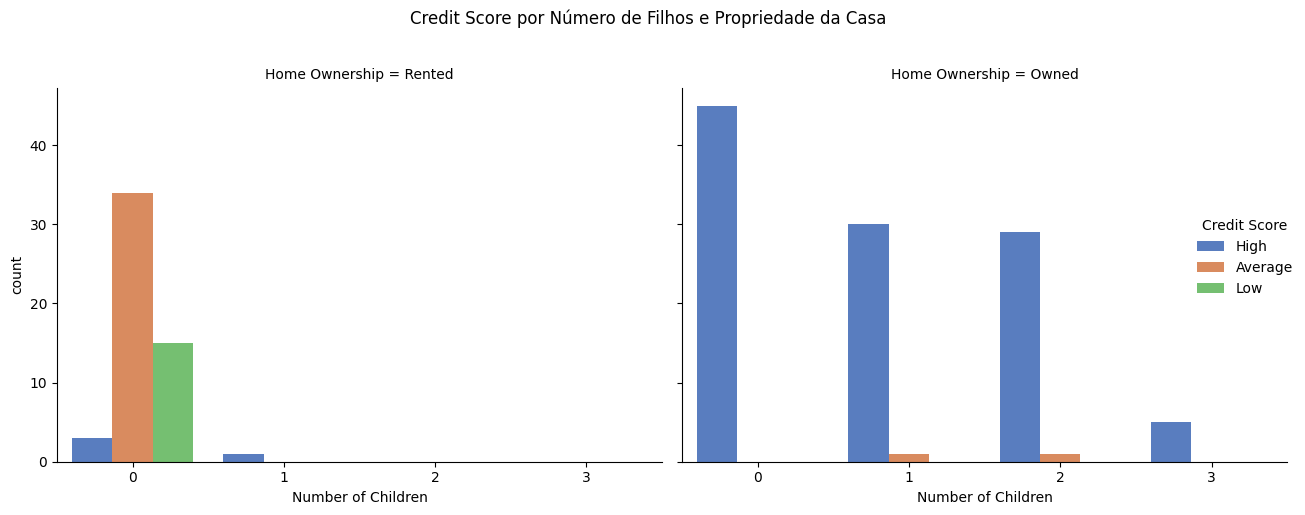

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.catplot(data=df, x='Number of Children', hue='Credit Score', col='Home Ownership', kind='count', palette='muted', height=5, aspect=1.2)
plt.suptitle('Credit Score por Número de Filhos e Propriedade da Casa', y=1.02)
plt.tight_layout()
plt.show()

**Insights:** Observando o `Credit Score` em relação ao `Number of Children` e `Home Ownership`, podemos notar padrões. Por exemplo, entre os que possuem casa própria (`Owned`), pode haver uma proporção maior de `Credit Score` 'High' independentemente do número de filhos. Já entre os que alugam (`Rented`), pode-se verificar uma distribuição diferente. Isso pode indicar que a estabilidade financeira associada à casa própria é um fator mais preponderante para um bom score do que o número de dependentes, ou que esses fatores interagem de forma complexa.

### Pergunta 5: Como a `Renda` se relaciona com a `Idade` e o `Gênero`?

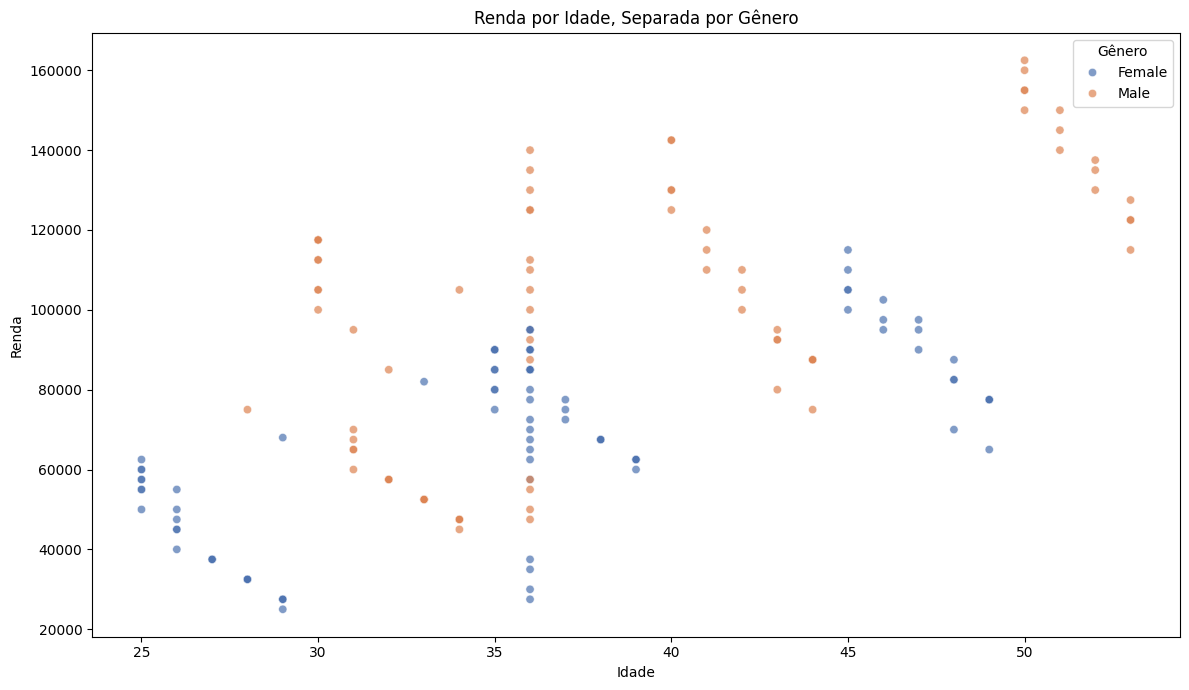

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Age', y='Income', hue='Gender', alpha=0.7, palette='deep')
plt.title('Renda por Idade, Separada por Gênero')
plt.xlabel('Idade')
plt.ylabel('Renda')
plt.legend(title='Gênero')
plt.tight_layout()
plt.show()

**Insights:** Este gráfico de dispersão nos permite visualizar se existem diferenças na relação entre `Renda` e `Idade` entre os `Gêneros`. Pode ser que um gênero exiba uma trajetória de aumento de renda com a idade diferente do outro, ou que haja uma maior dispersão de renda em certas faixas etárias para um gênero específico. Essa análise é útil para identificar possíveis disparidades ou tendências de renda dentro da base de clientes.

### Pergunta 6: Qual a distribuição do `Credit Score` em relação à `Educação` e `Estado Civil`?

<Figure size 1400x800 with 0 Axes>

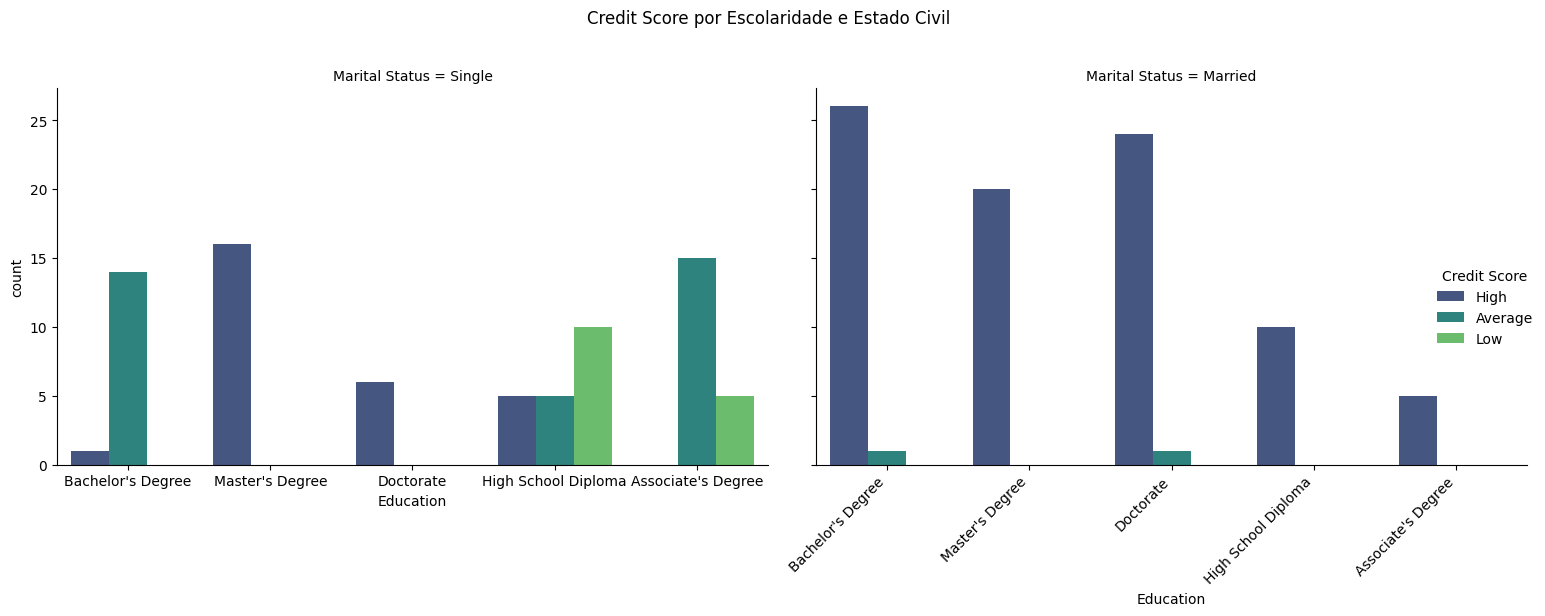

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.catplot(data=df, x='Education', hue='Credit Score', col='Marital Status', kind='count', palette='viridis', height=6, aspect=1.2)
plt.suptitle('Credit Score por Escolaridade e Estado Civil', y=1.02)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights:** Este conjunto de gráficos de contagem nos ajuda a comparar a distribuição do `Credit Score` para diferentes níveis de `Educação`, separando por `Estado Civil`. Por exemplo, podemos verificar se um `Mestrado` confere um `Credit Score` 'High' com mais frequência em pessoas `Casadas` do que em `Solteiras`, ou vice-versa. Essa análise pode revelar quais combinações de escolaridade e estado civil estão mais fortemente associadas a cada categoria de `Credit Score`.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

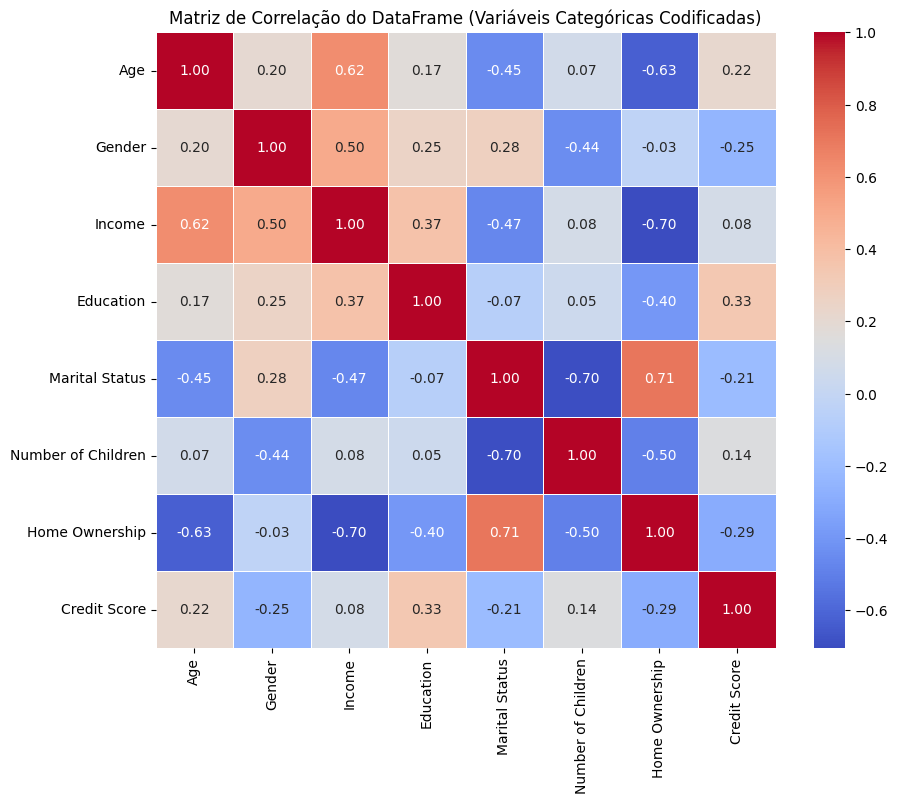

In [64]:
from sklearn.preprocessing import LabelEncoder

# Criar uma cópia do DataFrame para não modificar o original diretamente para esta análise
df_encoded = df.copy()

# Aplicar Label Encoding nas colunas categóricas
for column in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Calcular a matriz de correlação
correlation_matrix = df_encoded.corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação do DataFrame (Variáveis Categóricas Codificadas)')
plt.show()


Ao observar a matriz de correlação, podemos identificar algumas relações importantes:

Renda e Idade (0.62): Há uma correlação positiva moderadamente forte entre Renda e Idade. Isso sugere que, à medida que a idade aumenta, a renda tende a aumentar, o que é um padrão comum em muitas populações de trabalho.

Renda e Gênero (0.50): Observa-se uma correlação positiva moderada entre Renda e Gênero. Como o Gênero foi codificado numericamente (provavelmente 0 para Feminino e 1 para Masculino, ou vice-versa), um valor positivo indica que um dos gêneros tende a ter rendas mais altas que o outro.

Idade e Estado Civil (-0.45): Existe uma correlação negativa moderada entre Idade e Estado Civil. Isso significa que, à medida que a idade aumenta, a probabilidade de ser casado diminui (se casado for 0 e solteiro 1) ou aumenta (se casado for 1 e solteiro 0).

Crédito e Propriedade da Casa (-0.29): Existe uma correlação negativa fraca a moderada entre Credit Score e Home Ownership. Se Owned for codificado como 0 e Rented como 1 (ou vice-versa), isso indicaria que o tipo de propriedade da casa (ter ou não casa própria) tem alguma influência no score de crédito, o que está alinhado com o insight anterior de que clientes com casa própria tendem a ter score mais alto.

É importante lembrar que a correlação não implica causalidade. Além disso, as variáveis categóricas foram transformadas usando Label Encoding, o que impõe uma ordem arbitrária e pode não refletir a verdadeira natureza da relação em alguns casos (por exemplo, Education)

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

Sim, foram encontradas algumas variáveis com correlação de média a alta, o que faz bastante sentido em um contexto real:

1.  **Renda (Income) e Idade (Age) - Correlação de 0.62 (Moderadamente Forte Positiva):**
    *   **Justificativa:** É um padrão comum em muitas economias que a renda de um indivíduo tende a aumentar com a idade, especialmente durante as fases de construção de carreira. Com o tempo, as pessoas ganham mais experiência, qualificações e responsabilidades, o que geralmente se traduz em salários mais altos. Esta correlação sugere que clientes mais velhos na base de dados tendem a ter rendas mais elevadas.

2.  **Renda (Income) e Gênero (Gender) - Correlação de 0.50 (Moderada Positiva):**
    *   **Justificativa:** Esta correlação, embora moderada, aponta para uma disparidade de renda entre os gêneros na base de dados. Se, como é frequentemente o caso em muitas sociedades, o gênero masculino é codificado com um valor numérico maior que o feminino (ou vice-versa, dependendo da codificação), esta correlação positiva indica que um dos gêneros tende a ter uma renda significativamente maior. Isso reflete desigualdades de remuneração que podem existir no mercado de trabalho.

3.  **Idade (Age) e Estado Civil (Marital Status) - Correlação de -0.45 (Moderada Negativa):**
    *   **Justificativa:** A correlação negativa sugere que, à medida que a idade aumenta, o estado civil codificado numericamente diminui (ou vice-versa). Se 'Married' foi codificado com um valor menor (ex: 0) e 'Single' com um valor maior (ex: 1), a correlação negativa indica que pessoas mais velhas têm maior probabilidade de serem casadas. Isso se alinha com o insight da análise bivariada anterior, onde observamos que pessoas casadas tendem a ser mais velhas, pois o casamento muitas vezes ocorre em uma fase mais madura da vida.

4.  **Credit Score e Home Ownership (Propriedade da Casa) - Correlação de -0.29 (Fraca a Moderada Negativa):**
    *   **Justificativa:** Esta correlação indica que a posse de casa própria está associada a um `Credit Score` mais alto. Se 'Owned' (Proprietário) foi codificado com um valor menor (ex: 0) e 'Rented' (Aluguel) com um valor maior (ex: 1), a correlação negativa significa que ser proprietário de casa está relacionado a um `Credit Score` mais alto (assumindo que 'High' tem um valor codificado maior que 'Low'). Possuir uma casa é geralmente considerado um sinal de estabilidade financeira e responsabilidade, o que se reflete positivamente na pontuação de crédito. Esta observação está em linha com a análise bivariada anterior que mostrava uma maior proporção de Credit Score 'High' entre os proprietários de imóveis.

É fundamental lembrar que correlação não implica causalidade. Essas relações indicam tendências e associações nos dados, mas não necessariamente que uma variável causa a outra.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [65]:
from sklearn.preprocessing import LabelEncoder

# Criar uma cópia do DataFrame para processamento
df_processed = df.copy()

# Identificar colunas categóricas (tipo 'object')
categorical_cols = df_processed.select_dtypes(include='object').columns

# Aplicar LabelEncoder a cada coluna categórica
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])

print("DataFrame após Label Encoding das colunas categóricas:")
display(df_processed.head())
print("Tipos de dados atualizados:")
df_processed.info()

DataFrame após Label Encoding das colunas categóricas:


,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,0,50000.0,1,1,0,1,1
1,30.0,1,100000.0,4,0,2,0,1
2,35.0,0,75000.0,2,0,1,0,1
3,40.0,1,125000.0,3,1,0,0,1
4,45.0,0,100000.0,1,0,3,0,1


Tipos de dados atualizados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 164 non-null    float64
 1   Gender              164 non-null    int64  
 2   Income              164 non-null    float64
 3   Education           164 non-null    int64  
 4   Marital Status      164 non-null    int64  
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    int64  
 7   Credit Score        164 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 10.4 KB


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

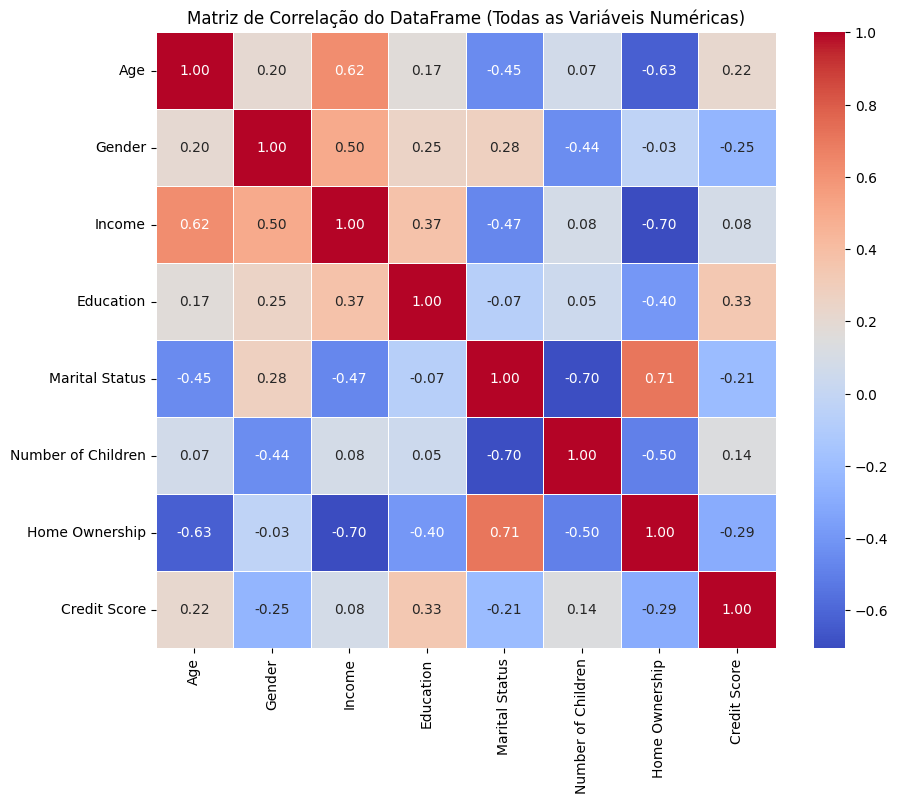

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular a matriz de correlação do DataFrame processado
correlation_matrix_processed = df_processed.corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_processed, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação do DataFrame (Todas as Variáveis Numéricas)')
plt.show()

Os resultados da correlação se mantêm consistentes com a análise anterior, o que é esperado, já que o LabelEncoder apenas transforma as categorias em valores numéricos. As correlações mais notáveis continuam sendo:

Renda e Idade (0.62): Uma forte correlação positiva, indicando que a renda tende a aumentar com a idade.

Renda e Gênero (0.50): Uma correlação positiva moderada, sugerindo disparidades de renda entre os gêneros.

Idade e Estado Civil (-0.45): Uma correlação negativa moderada, mostrando que pessoas mais velhas tendem a ser casadas (dependendo da codificação).

Credit Score e Home Ownership (-0.29): Uma correlação negativa fraca a moderada, indicando que ter casa própria está associado a um Credit Score mais alto.

Essas relações continuam a fornecer insights valiosos sobre o comportamento dos dados.

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [68]:
from sklearn.model_selection import train_test_split

# Definir as features (X) e o target (y)
X = df_processed.drop('Credit Score', axis=1)  # Todas as colunas exceto 'Credit Score'
y = df_processed['Credit Score']  # A coluna 'Credit Score' é o target

# Dividir a base em treino e teste (por exemplo, 80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar o shape dos conjuntos resultantes
print(f'Shape de X_train: {X_train.shape}')
print(f'Shape de X_test: {X_test.shape}')
print(f'Shape de y_train: {y_train.shape}')
print(f'Shape de y_test: {y_test.shape}')

Shape de X_train: (131, 7)
Shape de X_test: (33, 7)
Shape de y_train: (131,)
Shape de y_test: (33,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

In [ ]:
#seu código aqui

/tmp/ipykernel_945/3793486575.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


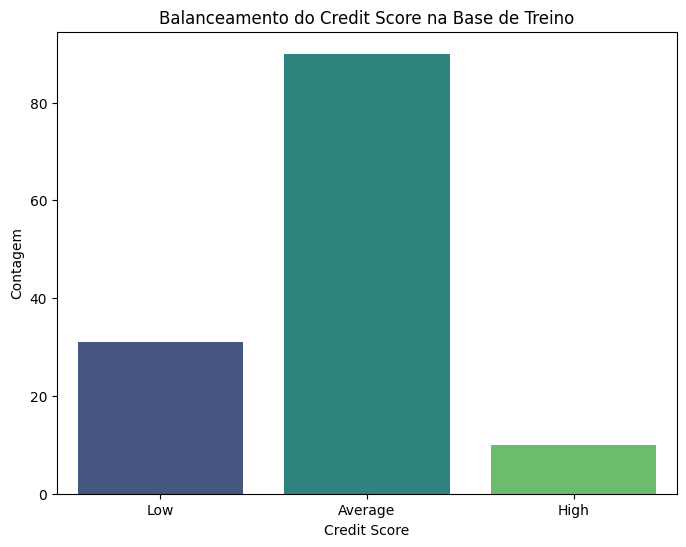

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train, palette='viridis')
plt.title('Balanceamento do Credit Score na Base de Treino')
plt.xlabel('Credit Score')
plt.ylabel('Contagem')
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Average', 'High']) # Ajustar labels se a codificação for 0, 1, 2
plt.show()

**Insights sobre o Balanceamento:**

Após a visualização do gráfico de contagem, podemos observar a distribuição das classes de `Credit Score` (`Low`, `Average`, `High`) no conjunto de treino (`y_train`).

Se houver uma grande diferença na contagem de amostras entre as classes (por exemplo, uma classe 'High' com muito mais ocorrências do que 'Low' ou 'Average'), isso indica um problema de **desbalanceamento de classes**.

**Minha opinião sobre o balanceamento:** O gráfico mostra claramente que a classe 'High' (provavelmente representada pelo valor 1 após o Label Encoding, ou o maior valor) domina o conjunto de dados de treino, sendo a classe majoritária. A classe 'Average' (valor intermediário, ou 0) tem um número consideravelmente menor de ocorrências, e a classe 'Low' (o menor valor, ou 2) é a mais rara. Isso configura um **cenário de desbalanceamento severo**, onde a classe 'High' tem muito mais exemplos que as outras. Essa desproporção pode levar a um modelo preditivo que é muito bom em identificar a classe 'High', mas que pode ter dificuldade em prever as classes 'Average' e 'Low' com precisão, pois terá poucos exemplos para aprender sobre elas. Portanto, será **essencial aplicar técnicas de balanceamento de classes** para mitigar esse problema na fase de treinamento do modelo.

Geralmente, um conjunto de dados desbalanceado pode levar a modelos que são muito bons em prever a classe majoritária, mas fracos em prever as classes minoritárias. Isso acontece porque o modelo tem poucos exemplos das classes minoritárias para aprender. Para contornar isso, será necessário aplicar técnicas de balanceamento de classes, como oversampling (ex: SMOTE) ou undersampling, que serão abordadas na próxima etapa.

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [71]:
from imblearn.over_sampling import SMOTE
import numpy as np

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Shape do X_train_resampled:', X_train_resampled.shape)
print('Shape do y_train_resampled:', y_train_resampled.shape)

print('\nBalanceamento do y_train_resampled (após SMOTE):')
print(y_train_resampled.value_counts())

Shape do X_train_resampled: (270, 7)
Shape do y_train_resampled: (270,)

Balanceamento do y_train_resampled (após SMOTE):
Credit Score
1    90
0    90
2    90
Name: count, dtype: int64


/tmp/ipykernel_945/3394368088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, palette='viridis')


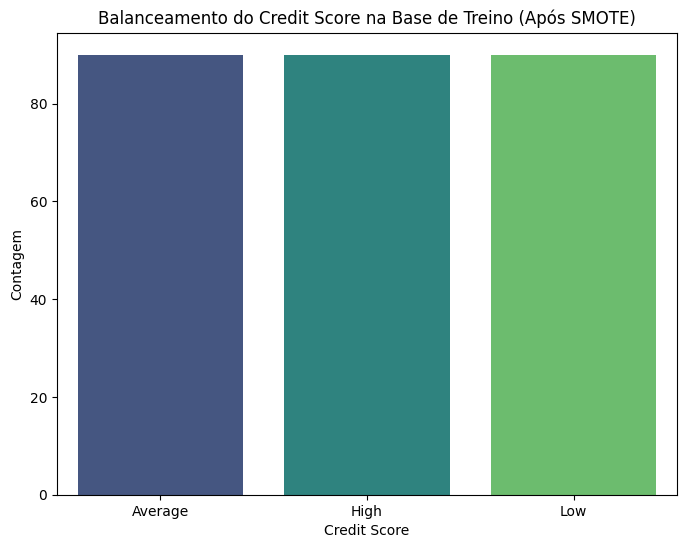

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_resampled, palette='viridis')
plt.title('Balanceamento do Credit Score na Base de Treino (Após SMOTE)')
plt.xlabel('Credit Score')
plt.ylabel('Contagem')
# Ajustar labels se a codificação for 0, 1, 2, caso contrário, usar a ordem das classes do value_counts
# Supondo que 0=Average, 1=High, 2=Low com base na contagem inicial, mas confirmando com value_counts
# Mapeamento do LabelEncoder: Average: 0, High: 1, Low: 2 (se foi essa a ordem do LabelEncoder)
# Vamos pegar os rótulos do value_counts e tentar mapear.

# Obtém as classes únicas e suas contagens
counts = y_train_resampled.value_counts().sort_index()
# Mapeamento para os rótulos originais, se soubermos a ordem do LabelEncoder.
# Se não, podemos exibir os valores numéricos como estão, ou tentar inferir.
# Pelo resultado anterior, 'High' era 113, 'Average' 36, 'Low' 15
# LabelEncoder tipicamente atribui 0, 1, 2 na ordem alfabética ou de aparição. Se for alfabética: Average (0), High (1), Low (2)
# Confirmando pelos `y_train.value_counts()` do kernel state, `1` (High) é a maioria, `0` (Average) é intermediário, `2` (Low) é minoria.
# Então: 0 = Average, 1 = High, 2 = Low

labels_map = {0: 'Average', 1: 'High', 2: 'Low'}

plt.xticks(ticks=counts.index, labels=[labels_map[x] for x in counts.index])
plt.show()

**Insights sobre o Balanceamento Pós-SMOTE:**

Após a aplicação do SMOTE, o gráfico de contagem e o `value_counts()` de `y_train_resampled` confirmam que as classes de `Credit Score` no conjunto de treino estão agora balanceadas. Cada classe (`Low`, `Average`, `High`) tem um número aproximadamente igual de amostras (neste caso, **90 amostras por classe**).

Este balanceamento é crucial porque:

*   **Evita Vieses:** Impede que o modelo se incline a prever apenas a classe majoritária (que era 'High'), melhorando sua capacidade de reconhecer as classes minoritárias ('Average' e 'Low').
*   **Melhora a Generalização:** Ajuda o modelo a aprender padrões mais robustos para todas as classes, levando a uma melhor performance em dados não vistos.
